# Preprocessing BUSI → UNeXt format

This notebook:
1. Collects all benign + malignant images (excludes normal)
2. Merges multiple masks into a single binary mask
3. Resizes images and masks to 500×500 px
4. Organizes in the format expected by UNeXt (`inputs/BUSI/images/` and `inputs/BUSI/masks/0/`)
5. Randomly splits into train (450) / validation (99) / test (98)
6. Saves each split's IDs in `.txt` files

In [1]:
import os
import re
import random
import numpy as np
import cv2
from glob import glob
from pathlib import Path
import shutil

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# ─── Path configuration ─────────────────────────────────────────────────
BASE_DIR   = "./"
BUSI_DIR   = os.path.join(BASE_DIR, "datasets", "BUSI")
UNEXT_DIR  = os.path.join(BASE_DIR, "UNeXt-pytorch-main")
INPUTS_DIR = os.path.join(UNEXT_DIR, "inputs", "BUSI")

IMG_OUT_DIR  = os.path.join(INPUTS_DIR, "images")
MASK_OUT_DIR = os.path.join(INPUTS_DIR, "masks", "0")  # UNeXt: one folder per class

IMG_SIZE = 500   # output resolution (px)
SEED     = 42

# Splits desejados
N_TRAIN = 450
N_VAL   = 99
N_TEST  = 98

# Categories used (normal is excluded)
CATEGORIES = ["benign", "malignant"]

# Create output directories
os.makedirs(IMG_OUT_DIR,  exist_ok=True)
os.makedirs(MASK_OUT_DIR, exist_ok=True)

print(f'Image output      : {IMG_OUT_DIR}')
print(f'Mask output       : {MASK_OUT_DIR}')

Image output      : ./UNeXt-pytorch-main/inputs/BUSI/images
Mask output       : ./UNeXt-pytorch-main/inputs/BUSI/masks/0


In [3]:
# ─── Helper functions ───────────────────────────────────────────────────────
from typing import Optional, List

def make_image_id(category: str, filename: str) -> Optional[str]:
    """Generates a clean ID from the filename.
    Ex.: 'benign (100).png' → 'benign_100'
    """
    m = re.search(r'\((\d+)\)', filename)
    return f"{category}_{m.group(1)}" if m else None


def find_mask_paths(category_dir: str, base_name: str) -> List[str]:
    """Returns all mask files associated with an image.
    Ex.: 'benign (100)' → ['benign (100)_mask.png', 'benign (100)_mask_1.png']
    """
    pattern = os.path.join(category_dir, f"{base_name}_mask*.png")
    return sorted(glob(pattern))


def merge_masks(mask_paths: List[str]) -> Optional[np.ndarray]:
    """Performs binary OR of all masks for an image.
    Returns uint8 mask with values 0 or 255.
    """
    combined = None
    for mp in mask_paths:
        m = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
        if m is None:
            print(f'  [warning] could not read mask: {mp}')
            continue
        if combined is None:
            combined = m.astype(np.uint16)
        else:
            combined = combined + m.astype(np.uint16)
    if combined is None:
        return None
    binary = np.zeros_like(combined, dtype=np.uint8)
    binary[combined > 0] = 255
    return binary


print('Functions defined.')

Functions defined.


In [4]:
# ─── Image processing ────────────────────────────────────────────────
image_ids = []
stats = {cat: {'total': 0, 'multi_mask': 0, 'no_mask': 0} for cat in CATEGORIES}

for category in CATEGORIES:
    cat_dir = os.path.join(BUSI_DIR, category)
    all_files = sorted(os.listdir(cat_dir))

    # Filter base images only (skip files with '_mask' in name)
    base_images = [f for f in all_files if f.endswith('.png') and '_mask' not in f]
    stats[category]['total'] = len(base_images)

    for img_file in base_images:
        base_name = os.path.splitext(img_file)[0]       # 'benign (100)'
        img_id    = make_image_id(category, img_file)   # 'benign_100'
        if img_id is None:
            print(f'  [warning] ID not generated for: {img_file}')
            continue

        # Carrega imagem
        img = cv2.imread(os.path.join(cat_dir, img_file))
        if img is None:
            print(f'  [warning] could not read: {img_file}')
            continue

        # Find and merge masks
        mask_paths = find_mask_paths(cat_dir, base_name)
        if not mask_paths:
            stats[category]['no_mask'] += 1
            print(f'  [warning] no mask for: {img_file}')
            continue
        if len(mask_paths) > 1:
            stats[category]['multi_mask'] += 1

        mask = merge_masks(mask_paths)
        if mask is None:
            print(f'  [warning] merge failed for: {img_file}')
            continue

        # Resize to 500×500
        img_r  = cv2.resize(img,  (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)
        mask_r = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
        # Re-binarize after resize (safety)
        mask_r[mask_r > 0] = 255

        # Save
        cv2.imwrite(os.path.join(IMG_OUT_DIR,  f'{img_id}.png'), img_r)
        cv2.imwrite(os.path.join(MASK_OUT_DIR, f'{img_id}.png'), mask_r)

        image_ids.append(img_id)

print(f'\nTotal processed images: {len(image_ids)}')
for cat, s in stats.items():
    print(f'  {cat}: {s["total"]} base | {s["multi_mask"]} multi-mask | {s["no_mask"]} no mask')


Total processed images: 647
  benign: 437 base | 16 multi-mask | 0 no mask
  malignant: 210 base | 1 multi-mask | 0 no mask


In [5]:
# ─── Train / validation / test split ──────────────────────────────────────
random.seed(SEED)
shuffled = image_ids.copy()
random.shuffle(shuffled)

total = len(shuffled)
target = N_TRAIN + N_VAL + N_TEST

if total < target:
    # Proportional adjustment if fewer images than expected
    ratio = total / target
    n_train = round(N_TRAIN * ratio)
    n_val   = round(N_VAL   * ratio)
    n_test  = total - n_train - n_val
    print(f'[warning] Only {total} images available. Split adjusted proportionally.')
else:
    n_train, n_val, n_test = N_TRAIN, N_VAL, N_TEST
    if total > target:
        print(f'[info] {total} images available; {total - target} will not be used in any split.')

train_ids = shuffled[:n_train]
val_ids   = shuffled[n_train : n_train + n_val]
test_ids  = shuffled[n_train + n_val : n_train + n_val + n_test]

print(f'\nTrain      : {len(train_ids)} images')
print(f'Validation : {len(val_ids)} images')
print(f'Test       : {len(test_ids)} images')
print(f'Total usado: {len(train_ids) + len(val_ids) + len(test_ids)} de {total}')


Train      : 450 images
Validation : 99 images
Test       : 98 images
Total usado: 647 de 647


In [6]:
# ─── Save split IDs to .txt files ─────────────────────────────
splits = {"train": train_ids, "val": val_ids, "test": test_ids}

for split_name, ids in splits.items():
    out_path = os.path.join(INPUTS_DIR, f"{split_name}_ids.txt")
    with open(out_path, 'w') as f:
        f.write('\n'.join(ids))
    print(f'Saved: {out_path}  ({len(ids)} IDs)')

Saved: ./UNeXt-pytorch-main/inputs/BUSI/train_ids.txt  (450 IDs)
Saved: ./UNeXt-pytorch-main/inputs/BUSI/val_ids.txt  (99 IDs)
Saved: ./UNeXt-pytorch-main/inputs/BUSI/test_ids.txt  (98 IDs)


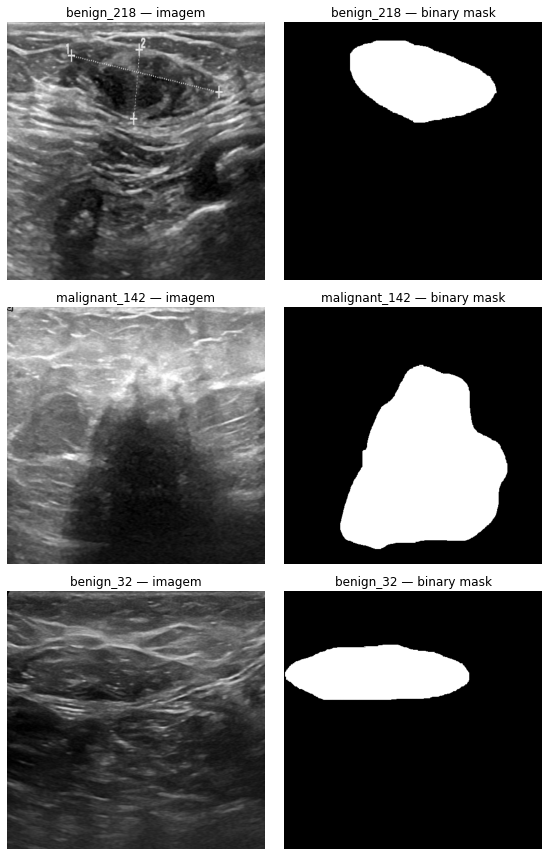

Image shape     : (500, 500, 3)   (expected: 500×500×3)
Mask shape: (500, 500)  (expected: 500×500)
Unique values in mask: [  0 255]


In [7]:
# ─── Visual verification of one sample ───────────────────────────────────────
import matplotlib.pyplot as plt

sample_ids = train_ids[:3]
fig, axes = plt.subplots(len(sample_ids), 2, figsize=(8, 4 * len(sample_ids)))

for i, img_id in enumerate(sample_ids):
    img  = cv2.cvtColor(cv2.imread(os.path.join(IMG_OUT_DIR,  f'{img_id}.png')), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(os.path.join(MASK_OUT_DIR, f'{img_id}.png'), cv2.IMREAD_GRAYSCALE)

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f'{img_id} — imagem')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(mask, cmap='gray')
    axes[i, 1].set_title(f'{img_id} — binary mask')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

# Verify resolution
sample_img  = cv2.imread(os.path.join(IMG_OUT_DIR,  f'{sample_ids[0]}.png'))
sample_mask = cv2.imread(os.path.join(MASK_OUT_DIR, f'{sample_ids[0]}.png'), cv2.IMREAD_GRAYSCALE)
print(f'Image shape     : {sample_img.shape}   (expected: {IMG_SIZE}×{IMG_SIZE}×3)')
print(f'Mask shape: {sample_mask.shape}  (expected: {IMG_SIZE}×{IMG_SIZE})')
print(f'Unique values in mask: {np.unique(sample_mask)}')

## Output structure

```
UNeXt-pytorch-main/inputs/BUSI/
├── images/
│   ├── benign_1.png
│   ├── benign_2.png
│   └── ...
├── masks/
│   └── 0/
│       ├── benign_1.png
│       ├── benign_2.png
│       └── ...
├── train_ids.txt
├── val_ids.txt
└── test_ids.txt
```

Each entry in `masks/0/` is the unified binary mask (values 0 or 255), with resolution 500×500 px.